In [1]:
%load_ext autoreload
%autoreload 2

# !export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [2]:
import os
# os.chdir('D:/thesis_code/keypoint_matcher')
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

references.shape=torch.Size([20, 2])


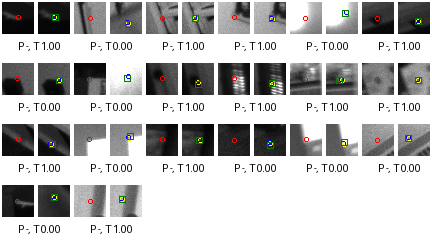

In [4]:
batch = next(iter(dl))
# ref_patches, references, tar_patches, targets, estimates, confidences = batch
ref_patches, references, tar_patches, targets, estimates, confidences, tar_patches_fake, targets_fake, estimates_fake = batch 
print(f'{references.shape=}')

count = 24 * 2

from utils import show_batch
show_batch(
    ref_patches, tar_patches,
    references, estimates, targets,

    confidences_true=confidences,
    estimates=estimates,

    limit_count=count,

    n_columns=6,
    just_gt=False,
)

# Light

In [5]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

9,639,619


In [6]:
pred = light(
    ref_patches, 
    tar_patches, 
    # references,
    estimates,
)

# target_coords = pred
# target_confidences = pred
target_coords, target_confidences = pred

print(f'{target_coords.shape=}')
print(f'{target_confidences.shape=}')

target_coords.shape=torch.Size([20, 2])
target_confidences.shape=torch.Size([20])


In [7]:
d = light._shared_step(batch)

In [8]:
# import torch
# from collections import Counter
# import matplotlib.pyplot as plt

# def analyze_dataset_stats(dataloader):
#     all_confidences = []
#     coord_dists = []

#     for batch in dataloader:
#         ref_patches, references, tar_patches, targets, estimates, confidences = batch

#         all_confidences.append(confidences.view(-1).cpu())

#         # Coordinate distance (L2) between estimates and targets
#         dist = torch.norm(targets.float() - estimates.float(), dim=1)
#         coord_dists.append(dist.cpu())

#     all_confidences = torch.cat(all_confidences)
#     coord_dists = torch.cat(coord_dists)

#     print(f"📦 Total samples: {len(all_confidences)}")
#     print(f"✅ Confidence stats:")
#     print(f"   - min:  {all_confidences.min().item():.4f}")
#     print(f"   - max:  {all_confidences.max().item():.4f}")
#     print(f"   - mean: {all_confidences.mean().item():.4f}")
#     print(f"   - std:  {all_confidences.std().item():.4f}")
#     print(f"   - #conf==0: {(all_confidences == 0).sum().item()}")
#     print(f"   - #conf==1: {(all_confidences == 1).sum().item()}")
    
#     print(f"\n📏 Coordinate distance stats (estimate → target):")
#     print(f"   - mean: {coord_dists.mean().item():.4f}")
#     print(f"   - std:  {coord_dists.std().item():.4f}")
#     print(f"   - min:  {coord_dists.min().item():.4f}")
#     print(f"   - max:  {coord_dists.max().item():.4f}")

#     # Plot confidence histogram
#     plt.figure(figsize=(6, 3))
#     plt.hist(all_confidences.numpy(), bins=20, color='skyblue', edgecolor='black')
#     plt.title("Confidence Distribution")
#     plt.xlabel("Confidence")
#     plt.ylabel("Count")
#     plt.grid(True, linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()


# analyze_dataset_stats(dl)
